In [1]:
import cv2
import numpy as np
import csv
import os
import glob
from tqdm.notebook import tqdm
from google.colab.patches import cv2_imshow

In [15]:
# setup for script
video_folder = "/content/drive/MyDrive/recruiting/voxel/CCTV01"
OUTPUT_CSV = "/content/drive/MyDrive/recruiting/voxel/stair_usage_log.csv"

MOTION_THRESHOLD = 450
STABLE_FRAMES = 5

In [8]:
# mapping polygons to different video files
polygon_1 = np.array([
    [510, 250],
    [450, 480],
    [50, 450],
    [400, 245]
], dtype=np.int32)

polygon_2 = np.array([
    [450, 250],
    [300, 460],
    [0, 450],
    [310, 250]
], dtype=np.int32)

polygon_map = {
    "VIRAT_S_010001": polygon_1,
    "VIRAT_S_010002": polygon_1,
    "VIRAT_S_010003": polygon_2,
    "VIRAT_S_010004": polygon_2,
    "VIRAT_S_010005": polygon_2
}

def get_stairs_polygon(video_path, default=polygon_1):
    video_name = os.path.basename(video_path)
    for prefix, poly in polygon_map.items():
        if video_name.startswith(prefix):
            return poly
    return default

In [4]:
# helper function for timestamp output
def frame_to_timestamp(frame_number, fps):
    seconds = frame_number / fps
    hh = int(seconds // 3600)
    mm = int((seconds % 3600) // 60)
    ss = seconds % 60
    return f"{hh:02d}:{mm:02d}:{ss:06.3f}"

In [6]:
# core logic for processing a single video
def process_video(video_path, stairs_pts, min_hold_seconds=2.0):
    """
    min_hold_seconds: minimum duration a new status must persist before
    it's accepted as a real state change (filters out momentary pauses,
    people stopping mid-stairs, brief motion noise, etc.)
    this is to help with 0-1 second duration events
    """
    video_name = os.path.basename(video_path)
    rows = []

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"  WARNING: could not open {video_name}, skipping")
        return rows

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not fps or fps <= 0:
        fps = 30.0

    min_hold_frames = int(min_hold_seconds * fps)

    backSub = cv2.createBackgroundSubtractorMOG2(varThreshold=15, detectShadows=True)

    ret, first_frame = cap.read()
    if not ret:
        print(f"  WARNING: could not read frames from {video_name}, skipping")
        cap.release()
        return rows

    h, w = first_frame.shape[:2]
    poly_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(poly_mask, [stairs_pts], 255)

    x, y, bw, bh = cv2.boundingRect(stairs_pts)
    mask_crop = poly_mask[y:y+bh, x:x+bw]

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    history = []
    frame_idx = 0

    confirmed_status = None # the "official" status currently logged
    segment_start_frame = 0

    candidate_status = None # a status that's trying to become confirmed
    candidate_start_frame = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        crop = frame[y:y+bh, x:x+bw]
        fgMask = backSub.apply(crop)
        fgMask = cv2.bitwise_and(fgMask, fgMask, mask=mask_crop)
        _, fgMask = cv2.threshold(fgMask, 150, 255, cv2.THRESH_BINARY)

        motion_pixels = cv2.countNonZero(fgMask)
        history.append(motion_pixels > MOTION_THRESHOLD)
        history = history[-STABLE_FRAMES:]
        in_use = sum(history) >= (STABLE_FRAMES // 2 + 1)

        raw_status = "in_use" if in_use else "idle"

        if confirmed_status is None:
            # first frame — initialize both confirmed and candidate
            confirmed_status = raw_status
            segment_start_frame = frame_idx
            candidate_status = None

        elif raw_status == confirmed_status:
            # signal agrees with current confirmed status — reset any
            # pending candidate, nothing to do
            candidate_status = None

        else:
            # signal disagrees with confirmed status — this might be a
            # real change or just a blip
            if candidate_status != raw_status:
                # new candidate started
                candidate_status = raw_status
                candidate_start_frame = frame_idx

            candidate_duration = frame_idx - candidate_start_frame + 1

            if candidate_duration >= min_hold_frames:
                # candidate has persisted long enough — commit the switch
                rows.append({
                    "video": video_name,
                    "status": confirmed_status,
                    "start_time": frame_to_timestamp(segment_start_frame, fps),
                    "end_time": frame_to_timestamp(candidate_start_frame - 1, fps)
                })
                confirmed_status = candidate_status
                segment_start_frame = candidate_start_frame
                candidate_status = None

        frame_idx += 1

    if confirmed_status is not None:
        rows.append({
            "video": video_name,
            "status": confirmed_status,
            "start_time": frame_to_timestamp(segment_start_frame, fps),
            "end_time": frame_to_timestamp(frame_idx - 1, fps)
        })

    cap.release()
    print(f"  {video_name}: {len(rows)} segments, {frame_idx} frames")
    return rows

In [13]:
# logic for handling multiple videos
def batch_process(video_paths, output_csv):
    fieldnames = ["video", "status", "start_time", "end_time"]
    total_segments = 0
    failed_videos = []

    with open(output_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        f.flush()

        for video_path in tqdm(video_paths, desc="Processing videos", unit="video"):
            video_name = os.path.basename(video_path)
            stairs_pts = get_stairs_polygon(video_path)

            try:
                rows = process_video(video_path, stairs_pts)

                if rows:
                    writer.writerows(rows)
                    f.flush()          # force Python's buffer to the OS
                    os.fsync(f.fileno())  # force OS buffer to actual disk/Drive
                    total_segments += len(rows)
                else:
                    failed_videos.append(video_name)

            except Exception as e:
                # don't let one bad video kill the whole batch
                print(f"  ERROR processing {video_name}: {e}")
                failed_videos.append(video_name)
                continue

    print(f"\nDone. Wrote {total_segments} total segments "
          f"across {len(video_paths) - len(failed_videos)}/{len(video_paths)} videos "
          f"to {output_csv}")

    if failed_videos:
        print(f"\n{len(failed_videos)} video(s) failed or produced no output:")
        for v in failed_videos:
            print(f"  - {v}")

In [16]:
video_files = sorted(glob.glob(os.path.join(video_folder, "VIRAT_S_01*.mp4")))

if not video_files:
    print(f"No video files found in {video_folder}")
else:
    print(f"Found {len(video_files)} video(s) to process")
    batch_process(video_files, OUTPUT_CSV)

Found 45 video(s) to process


Processing videos:   0%|          | 0/45 [00:00<?, ?video/s]

  VIRAT_S_010000_00_000000_000165.mp4: 9 segments, 3956 frames
  VIRAT_S_010000_01_000184_000324.mp4: 7 segments, 3267 frames
  VIRAT_S_010000_02_000388_000421.mp4: 5 segments, 592 frames
  VIRAT_S_010000_03_000442_000528.mp4: 7 segments, 1907 frames
  VIRAT_S_010000_04_000530_000605.mp4: 2 segments, 1752 frames
  VIRAT_S_010000_05_000638_000718.mp4: 5 segments, 1711 frames
  VIRAT_S_010000_06_000728_000762.mp4: 3 segments, 766 frames
  VIRAT_S_010000_07_000827_000860.mp4: 2 segments, 615 frames
  VIRAT_S_010000_08_000893_001024.mp4: 4 segments, 2817 frames
  VIRAT_S_010001_00_000019_000065.mp4: 3 segments, 1059 frames
  VIRAT_S_010001_01_000071_000167.mp4: 7 segments, 2253 frames
  VIRAT_S_010001_02_000195_000498.mp4: 9 segments, 7188 frames
  VIRAT_S_010001_03_000537_000563.mp4: 3 segments, 496 frames
  VIRAT_S_010001_04_000583_000646.mp4: 3 segments, 1485 frames
  VIRAT_S_010001_05_000649_000684.mp4: 3 segments, 646 frames
  VIRAT_S_010001_06_000685_000722.mp4: 2 segments, 807 frame

SCRATCH WORK - helper function to confirm the area of interest

Frame shape (height, width, channels): (720, 1280, 3)


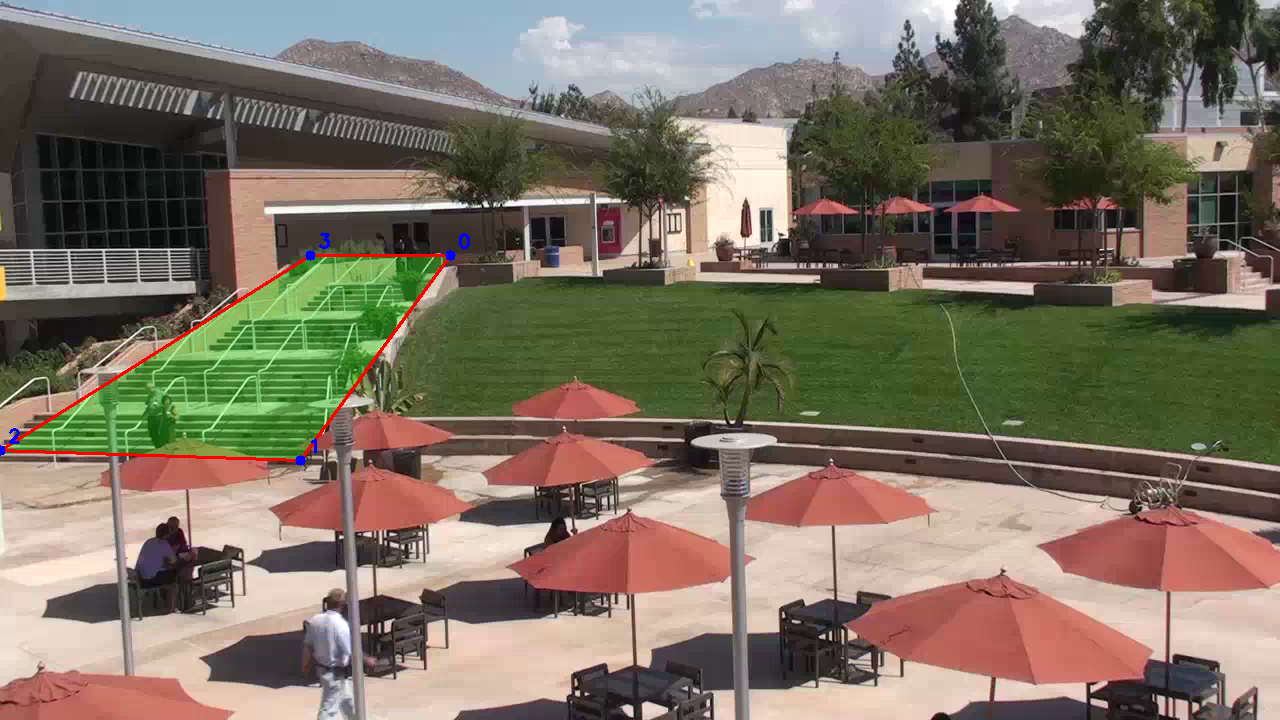

In [107]:
stairs_pts = np.array([
    [450, 255],
    [300, 460],
    [0, 450],
    [310, 255]
], dtype=np.int32)

def preview_polygon(video_path, stairs_pts, frame_number=0):
    """
    Draws the stairs polygon on a specific frame so you can visually
    verify it lines up correctly before running detection.
    """
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()
    print("Frame shape (height, width, channels):", frame.shape)

    if not ret:
        raise RuntimeError(f"Could not read frame {frame_number} from {video_path}")

    overlay = frame.copy()

    # Semi-transparent fill so you can see the polygon shape clearly
    cv2.fillPoly(overlay, [stairs_pts], (0, 255, 0))
    blended = cv2.addWeighted(overlay, 0.3, frame, 0.7, 0)

    # Solid outline on top, plus numbered corner points so you can check
    # ordering (useful if the shape looks twisted/self-intersecting)
    cv2.polylines(blended, [stairs_pts], isClosed=True, color=(0, 0, 255), thickness=2)
    for i, (px, py) in enumerate(stairs_pts):
        cv2.circle(blended, (px, py), 5, (255, 0, 0), -1)
        cv2.putText(blended, str(i), (px + 8, py - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    cv2_imshow(blended)


# Example usage
preview_polygon("/content/drive/MyDrive/recruiting/voxel/CCTV01/VIRAT_S_010003_01_000111_000137.mp4", stairs_pts, frame_number=0)